# Generative vs Discriminative Model - MNIST (0 and 1)

Assignment: use MNIST digits 0 and 1, build a discriminative model (Logistic Regression) and a generative model (Autoencoder), compare them.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
from mlxtend.data import mnist_data

## Step 1: Load dataset and keep only 0 and 1

In [ ]:
X, y = mnist_data()
print(X.shape, y.shape)

# keep only 0 and 1
idx = (y == 0) | (y == 1)
X = X[idx]
y = y[idx]

X = X / 255.0  # scale pixels between 0 and 1

print(X.shape, y.shape)
print(np.unique(y, return_counts=True))

(5000, 784) (5000,)
(1000, 784) (1000,)
(array([0, 1]), array([500, 500]))


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(x_train.shape, x_test.shape)

(800, 784) (200, 784)


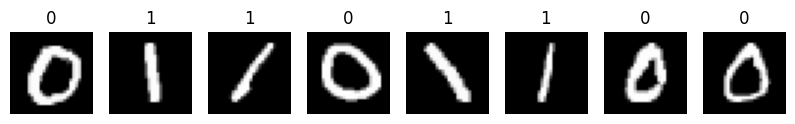

In [ ]:
# show some sample digits
plt.figure(figsize=(10,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

## Step 2: Discriminative model (Logistic Regression)

This model just learns to separate the two classes, it does not learn how to draw digits.

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

pred = model.predict(x_test)
acc = accuracy_score(y_test, pred)
print("accuracy =", acc)

accuracy = 0.995


In [ ]:
cm = confusion_matrix(y_test, pred)
print(cm)

[[ 95   1]
 [  0 104]]


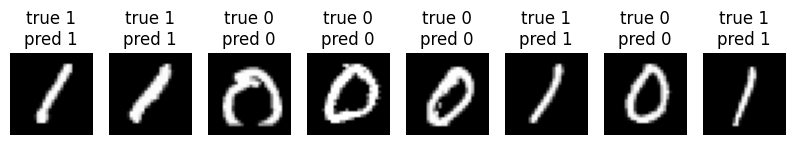

In [ ]:
# show predictions
plt.figure(figsize=(10,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"true {y_test[i]}\npred {pred[i]}")
    plt.axis('off')
plt.show()

## Step 3: Generative model (Autoencoder)

Here we don't use the labels at all. The model just tries to compress the image and rebuild it back. We use a small hidden layer of size 2 in the middle so the image gets squeezed to just 2 numbers.

In [ ]:
ae = MLPRegressor(hidden_layer_sizes=(128,32,2,32,128), max_iter=400, random_state=1)
ae.fit(x_train, x_train)   # input = output, no labels used

recon = ae.predict(x_test)
mse = np.mean((recon - x_test)**2)
print("reconstruction error =", mse)

reconstruction error = 0.04269841891307463


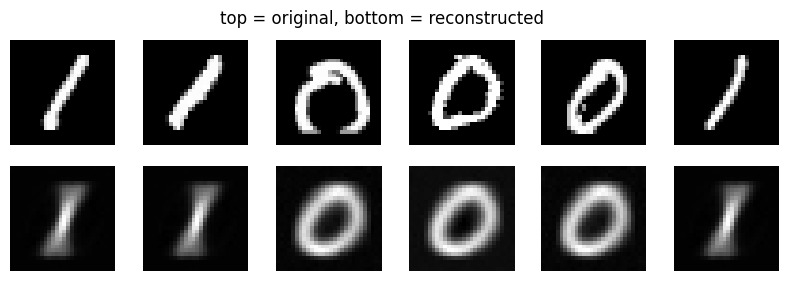

In [ ]:
# compare original vs reconstructed
plt.figure(figsize=(10,3))
for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.subplot(2,6,i+7)
    plt.imshow(recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.suptitle("top = original, bottom = reconstructed")
plt.show()

## Step 4: Generating new digit images

Since sklearn doesn't let us use the middle layer directly, we take the weights out manually and build our own encoder/decoder function. Then we make up new random points near where 0's and 1's are and pass them through decoder to create new images.

In [ ]:
def relu(x):
    return np.maximum(0, x)

def encode(x):
    h = relu(x @ ae.coefs_[0] + ae.intercepts_[0])
    h = relu(h @ ae.coefs_[1] + ae.intercepts_[1])
    z = relu(h @ ae.coefs_[2] + ae.intercepts_[2])
    return z

def decode(z):
    h = relu(z @ ae.coefs_[3] + ae.intercepts_[3])
    h = relu(h @ ae.coefs_[4] + ae.intercepts_[4])
    out = h @ ae.coefs_[5] + ae.intercepts_[5]
    return np.clip(out, 0, 1)

z_train = encode(x_train)
print(z_train.shape)

(800, 2)


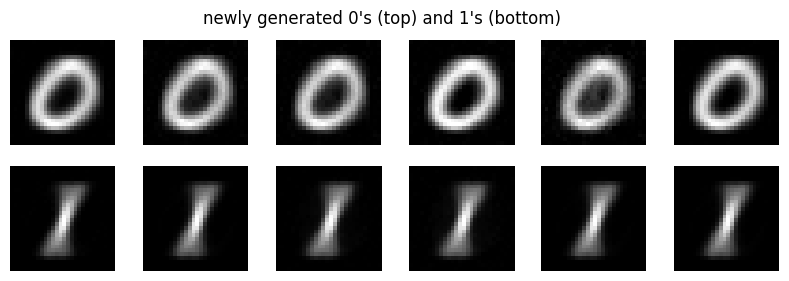

In [ ]:
# make new random points close to where each digit is, then decode them
mean0 = z_train[y_train==0].mean(axis=0)
std0 = z_train[y_train==0].std(axis=0)
mean1 = z_train[y_train==1].mean(axis=0)
std1 = z_train[y_train==1].std(axis=0)

new_z0 = mean0 + np.random.randn(6,2)*std0
new_z1 = mean1 + np.random.randn(6,2)*std1

new_0 = decode(new_z0)
new_1 = decode(new_z1)

plt.figure(figsize=(10,3))
for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(new_0[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.subplot(2,6,i+7)
    plt.imshow(new_1[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.suptitle("newly generated 0's (top) and 1's (bottom)")
plt.show()

## Step 5: Comparison

Accuracy of discriminative model and reconstruction error of generative model:

In [ ]:
print("Logistic Regression accuracy :", acc)
print("Autoencoder reconstruction MSE :", mse)

Logistic Regression accuracy : 0.995
Autoencoder reconstruction MSE : 0.04269841891307463


## Written comparison

The Logistic Regression model just learns a boundary to tell 0 and 1 apart, it never learns what the digit actually looks like. It only cares about the label.

The Autoencoder does not use any labels, it just learns to squeeze the image into a small code and rebuild it. Because of this it actually learns how the digits are shaped, and we can use it to make new digit images that were not in the dataset.

So the main difference is: discriminative model = learns a decision boundary between classes, generative model = learns how the data itself looks and can create new data.